<a href="https://www.kaggle.com/code/krishagrawalcffc/trashnet-classification?scriptVersionId=305672794" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os

data_path = "/kaggle/input/datasets/vishwasmishra1234/trash-net"

for folder in os.listdir(data_path):
    print(folder)
for folder in os.listdir(data_path):
    folder_path = os.path.join(data_path, folder)
    if os.path.isdir(folder_path):
        print(folder, ":", len(os.listdir(folder_path)))

train_imgEFFICIENTNET
val_imgEFFICIENTNET
train_imgEFFICIENTNET : 4
val_imgEFFICIENTNET : 4


In [2]:
import os
import matplotlib.pyplot as plt
import cv2
import random
from sklearn.metrics import confusion_matrix   
def show_images(split, class_name):
    folder = os.path.join(data_path, split, class_name)
    
    print("Using path:", folder)  # debug (important)
    
    if not os.path.exists(folder):
        print("❌ Wrong path. Check split/class name.")
        return
    
    images = os.listdir(folder)
    
    plt.figure(figsize=(10,5))
    
    for i in range(5):
        img_path = os.path.join(folder, random.choice(images))
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis("off")
    
    plt.suptitle(f"{split} - {class_name}")
    plt.show()

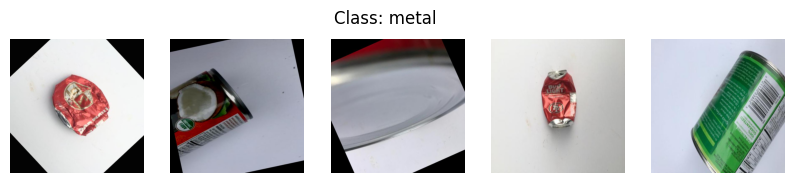

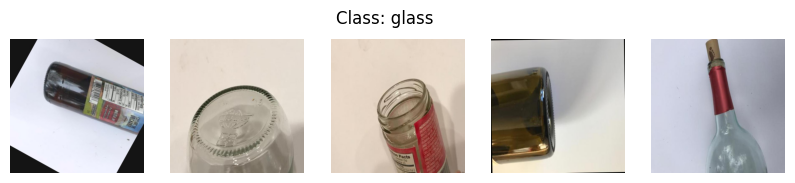

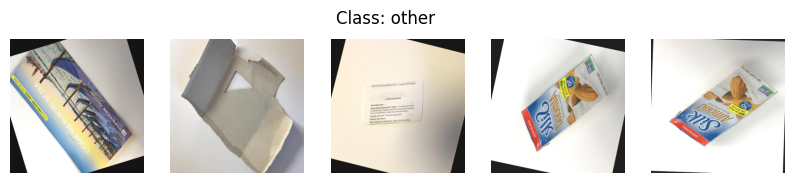

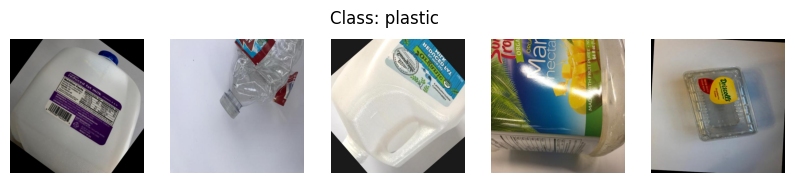

In [3]:
train_path = os.path.join(data_path, "train_imgEFFICIENTNET")
classes = os.listdir(train_path)

for cls in classes:
    folder = os.path.join(train_path, cls)
    images = os.listdir(folder)
    
    plt.figure(figsize=(10,2))
    
    for i in range(5):
        img_path = os.path.join(folder, random.choice(images))
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis("off")
    
    plt.suptitle(f"Class: {cls}")
    plt.show()

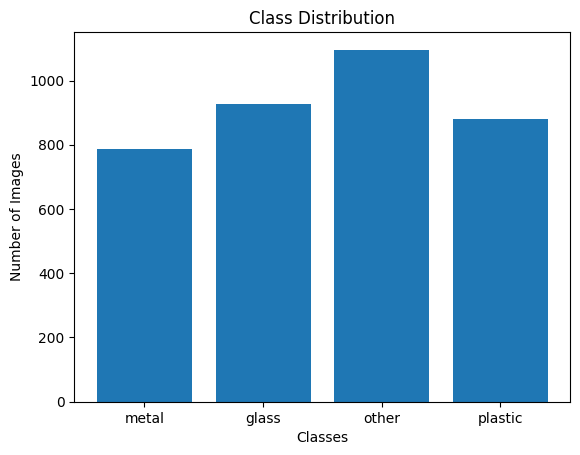

In [4]:
class_counts = {}

for cls in classes:
    class_counts[cls] = len(os.listdir(os.path.join(train_path, cls)))

plt.bar(class_counts.keys(), class_counts.values())
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [5]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_path = "/kaggle/input/datasets/vishwasmishra1234/trash-net/train_imgEFFICIENTNET"
val_path = "/kaggle/input/datasets/vishwasmishra1234/trash-net/val_imgEFFICIENTNET"

In [6]:
#data augmentation for increasing dataset
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),  # kept, safe
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],         # ADD THIS
                         std=[0.229, 0.224, 0.225])
])

In [7]:
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [8]:
train_dataset = datasets.ImageFolder(train_path, transform=train_transforms)
val_dataset = datasets.ImageFolder(val_path, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [9]:
print(train_dataset.classes)

['glass', 'metal', 'other', 'plastic']


In [10]:
import timm
import torch.nn as nn

model = timm.create_model('efficientnet_b0', pretrained=True)

# Modify final layer
model.classifier = nn.Linear(model.classifier.in_features, 4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [11]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [12]:
num_epochs = 10
train_losses = []
val_losses = []
train_accs = []
val_accs = []

best_val_acc = 0
patience = 2
counter = 0

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = train_loss / total
    train_acc = 100 * correct / total
    
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / total
    val_acc = 100 * correct / total
    
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # ---- EARLY STOPPING ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1
    
    if counter >= patience:
        print("Early stopping triggered")
        break


Epoch 1/10
Train Loss: 0.5908 | Train Acc: 80.34%
Val Loss: 0.1886 | Val Acc: 94.82%

Epoch 2/10
Train Loss: 0.1714 | Train Acc: 94.26%
Val Loss: 0.1022 | Val Acc: 96.44%

Epoch 3/10
Train Loss: 0.0914 | Train Acc: 97.37%
Val Loss: 0.0608 | Val Acc: 98.70%

Epoch 4/10
Train Loss: 0.0470 | Train Acc: 98.56%
Val Loss: 0.0723 | Val Acc: 97.62%

Epoch 5/10
Train Loss: 0.0368 | Train Acc: 99.02%
Val Loss: 0.0490 | Val Acc: 98.60%
Early stopping triggered


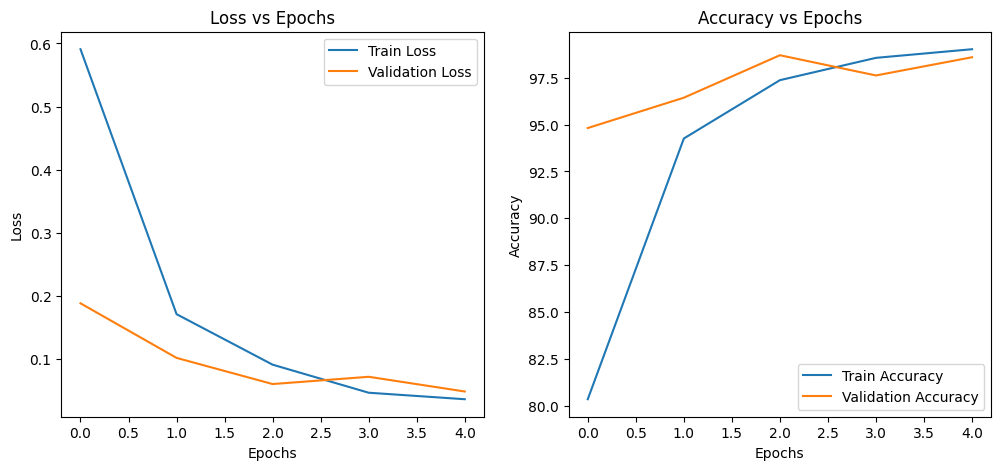

In [13]:
plt.figure(figsize=(12,5))

# Loss Plot
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")

# Accuracy Plot
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.show()

In [14]:
all_labels = []
all_preds = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())


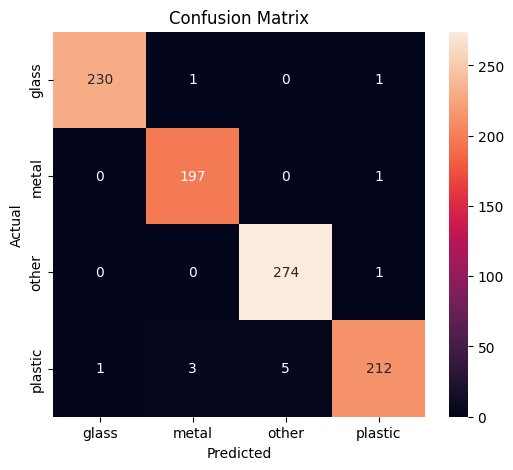

In [15]:
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 56.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


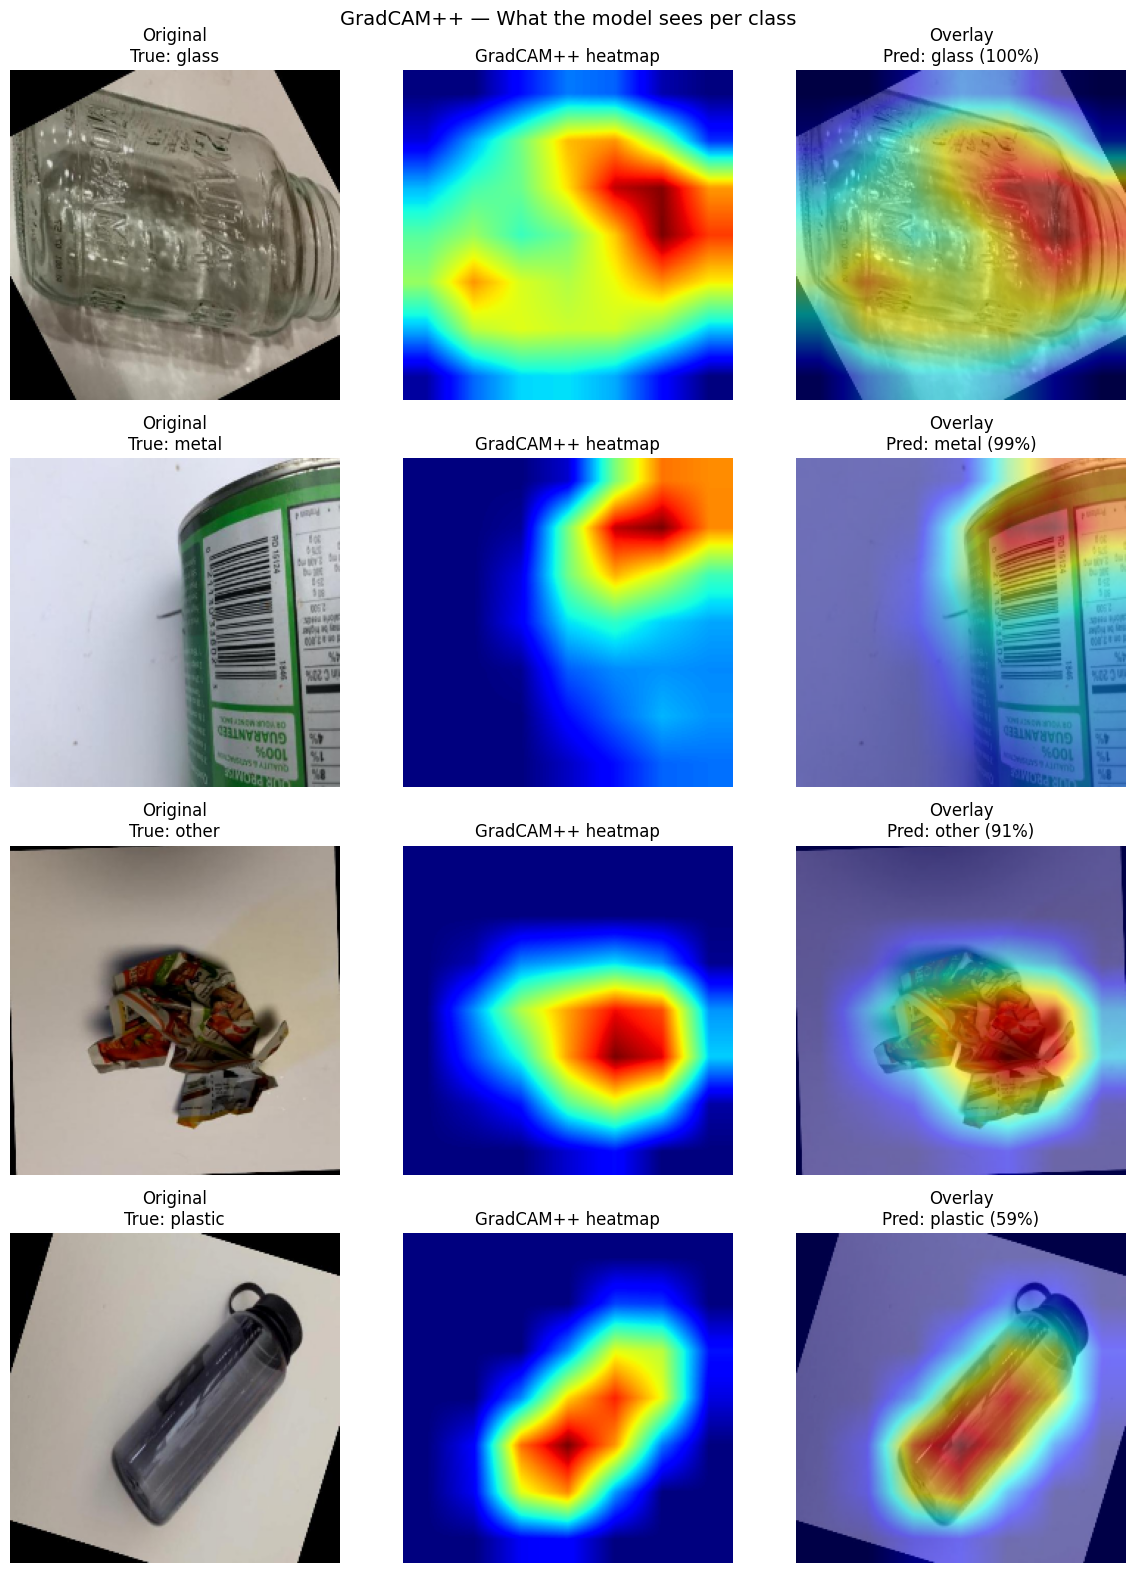

Saved to gradcam_results.png


In [17]:
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
import os

# Load best model
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
model = model.to(device)

# Target layer for EfficientNet-B0
target_layers = [model.conv_head]

# Pick 1 sample image per class
class_names = train_dataset.classes
val_path = "/kaggle/input/datasets/vishwasmishra1234/trash-net/val_imgEFFICIENTNET"

fig, axes = plt.subplots(len(class_names), 3, figsize=(12, 4 * len(class_names)))

for row, cls in enumerate(class_names):
    cls_path = os.path.join(val_path, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    # Load and preprocess
    raw_img = cv2.imread(img_path)
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
    raw_img = cv2.resize(raw_img, (224, 224))
    rgb_float = np.float32(raw_img) / 255.0

    input_tensor = val_transforms(
        __import__('PIL').Image.open(img_path).convert('RGB')
    ).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        pred_idx = output.argmax(dim=1).item()
        confidence = probs[0][pred_idx].item()

    # GradCAM++
    cam = GradCAMPlusPlus(model=model, target_layers=target_layers)
    targets = [ClassifierOutputTarget(pred_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    visualization = show_cam_on_image(rgb_float, grayscale_cam, use_rgb=True)

    # Plot
    axes[row, 0].imshow(raw_img)
    axes[row, 0].set_title(f"Original\nTrue: {cls}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(grayscale_cam, cmap='jet')
    axes[row, 1].set_title("GradCAM++ heatmap")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(visualization)
    axes[row, 2].set_title(f"Overlay\nPred: {class_names[pred_idx]} ({confidence:.0%})")
    axes[row, 2].axis("off")

plt.suptitle("GradCAM++ — What the model sees per class", fontsize=14)
plt.tight_layout()
plt.savefig("gradcam_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to gradcam_results.png")

In [18]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

       glass       1.00      0.99      0.99       232
       metal       0.98      0.99      0.99       198
       other       0.98      1.00      0.99       275
     plastic       0.99      0.96      0.97       221

    accuracy                           0.99       926
   macro avg       0.99      0.99      0.99       926
weighted avg       0.99      0.99      0.99       926



In [19]:
# Display best results summary
print("=" * 50)
print("       MODEL PERFORMANCE SUMMARY")
print("=" * 50)
print(f"  Model        : EfficientNet-B0")
print(f"  Best Val Acc : {best_val_acc:.2f}%")
print(f"  Dataset      : TrashNet (4 classes)")
print("=" * 50)

       MODEL PERFORMANCE SUMMARY
  Model        : EfficientNet-B0
  Best Val Acc : 98.70%
  Dataset      : TrashNet (4 classes)


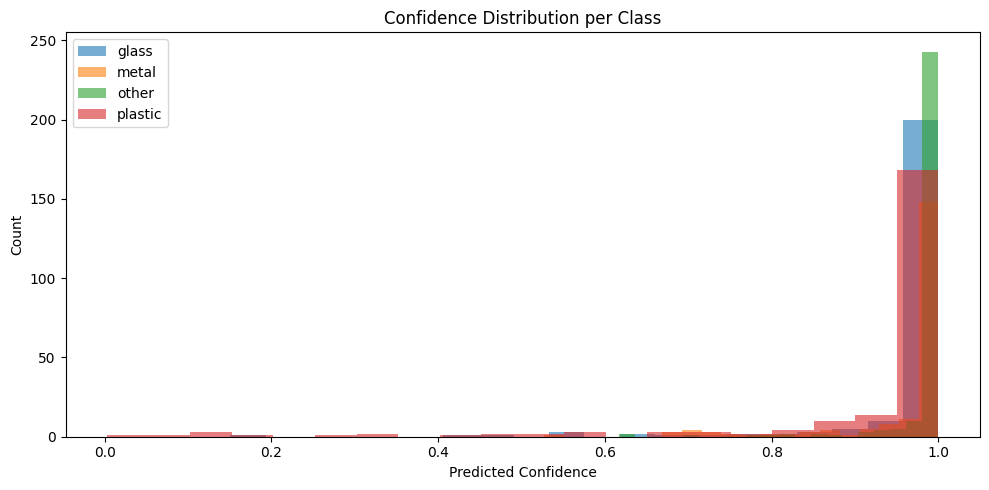

In [20]:
# Confidence distribution per class
from sklearn.metrics import classification_report
import torch.nn.functional as F

all_probs = []
model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)
all_labels_arr = np.array(all_labels)

fig, ax = plt.subplots(figsize=(10, 5))
for i, cls in enumerate(train_dataset.classes):
    cls_mask = all_labels_arr == i
    cls_probs = all_probs[cls_mask, i]
    ax.hist(cls_probs, bins=20, alpha=0.6, label=cls)

ax.set_xlabel("Predicted Confidence")
ax.set_ylabel("Count")
ax.set_title("Confidence Distribution per Class")
ax.legend()
plt.tight_layout()
plt.savefig("confidence_dist.png", dpi=150)
plt.show()

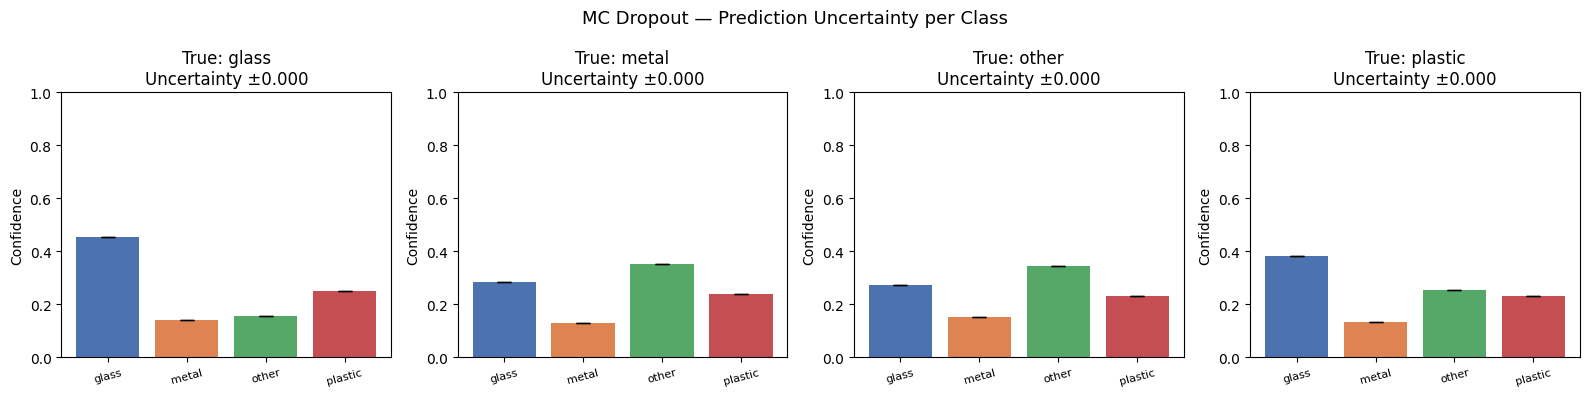

In [21]:
# MC Dropout — run same image 30 times with dropout ON
def mc_dropout_predict(model, input_tensor, n_samples=30):
    model.train()  # keeps dropout ON
    preds = []
    with torch.no_grad():
        for _ in range(n_samples):
            out = torch.softmax(model(input_tensor), dim=1)
            preds.append(out.cpu().numpy())
    model.eval()
    preds = np.array(preds)  # (30, 1, 4)
    mean = preds.mean(axis=0)[0]   # avg prediction
    std  = preds.std(axis=0)[0]    # uncertainty
    return mean, std

# Test on one image per class
fig, axes = plt.subplots(1, len(class_names), figsize=(16, 4))

for i, cls in enumerate(class_names):
    cls_path = os.path.join(val_path, cls)
    img_path = os.path.join(cls_path, random.choice(os.listdir(cls_path)))

    input_tensor = val_transforms(
        __import__('PIL').Image.open(img_path).convert('RGB')
    ).unsqueeze(0).to(device)

    mean, std = mc_dropout_predict(model, input_tensor)

    x = np.arange(len(class_names))
    axes[i].bar(x, mean, yerr=std, capsize=5,
                color=['#4C72B0','#DD8452','#55A868','#C44E52'])
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(class_names, rotation=15, fontsize=8)
    axes[i].set_title(f"True: {cls}\nUncertainty ±{std.max():.3f}")
    axes[i].set_ylim(0, 1)
    axes[i].set_ylabel("Confidence")

plt.suptitle("MC Dropout — Prediction Uncertainty per Class", fontsize=13)
plt.tight_layout()
plt.savefig("mc_dropout.png", dpi=150)
plt.show()